In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [5]:
df = pd.read_csv("C:\\Users\\USER\\Downloads\\diabetes (1).csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35.0,0.0,33.6,0.627,50,1.0
1,1,85,66,29.0,0.0,26.6,0.351,31,0.0
2,8,183,64,0.0,0.0,23.3,0.672,32,1.0
3,1,89,66,23.0,94.0,28.1,0.167,21,0.0
4,0,137,40,35.0,168.0,43.1,2.288,33,1.0
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48.0,180.0,32.9,0.171,63,0.0
764,2,122,70,27.0,0.0,36.8,0.340,27,0.0
765,5,121,72,23.0,112.0,26.2,0.245,30,0.0
766,1,126,60,0.0,0.0,30.1,0.349,47,1.0


In [6]:
print("First 5 rows:\n", df.head())
print("\nDataset Info:\n")
print(df.info())


First 5 rows:
    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72           35.0      0.0  33.6   
1            1       85             66           29.0      0.0  26.6   
2            8      183             64            0.0      0.0  23.3   
3            1       89             66           23.0     94.0  28.1   
4            0      137             40           35.0    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50      1.0  
1                     0.351   31      0.0  
2                     0.672   32      1.0  
3                     0.167   21      0.0  
4                     2.288   33      1.0  

Dataset Info:

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose  

In [7]:
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

df[cols] = df[cols].replace(0, np.nan)

df.fillna(df.mean(), inplace=True)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.000000,154.955443,33.6,0.627,50,1.0
1,1,85.0,66.0,29.000000,154.955443,26.6,0.351,31,0.0
2,8,183.0,64.0,29.100186,154.955443,23.3,0.672,32,1.0
3,1,89.0,66.0,23.000000,94.000000,28.1,0.167,21,0.0
4,0,137.0,40.0,35.000000,168.000000,43.1,2.288,33,1.0
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.000000,180.000000,32.9,0.171,63,0.0
764,2,122.0,70.0,27.000000,154.955443,36.8,0.340,27,0.0
765,5,121.0,72.0,23.000000,112.000000,26.2,0.245,30,0.0
766,1,126.0,60.0,29.100186,154.955443,30.1,0.349,47,1.0


In [8]:
cols

['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

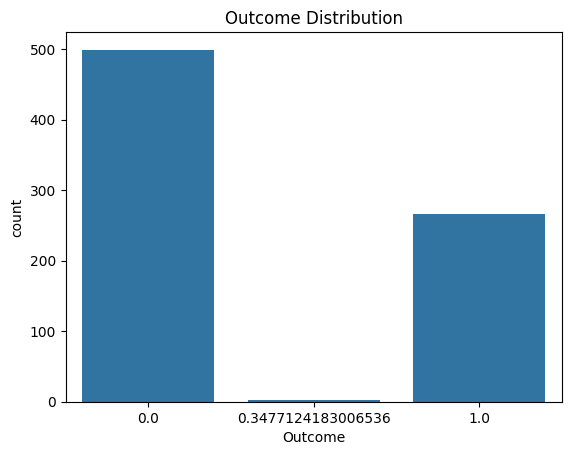

In [9]:
plt.figure()
sns.countplot(x="Outcome", data=df)
plt.title("Outcome Distribution")
plt.show()

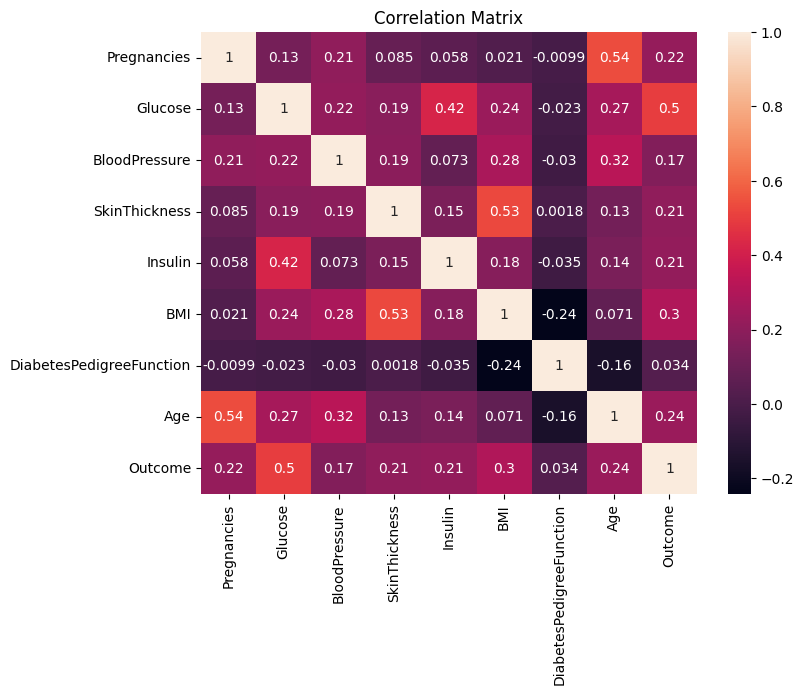

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

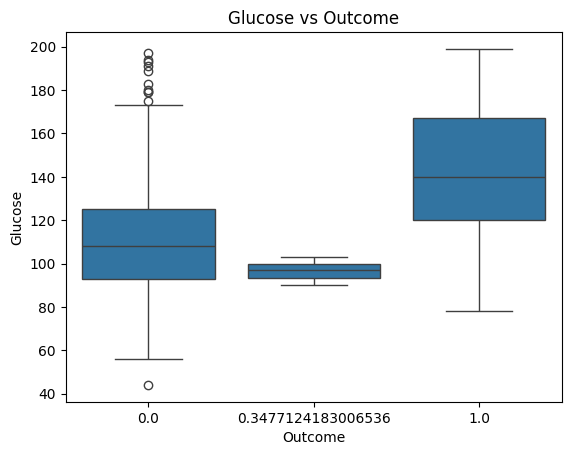

In [11]:
plt.figure()
sns.boxplot(x="Outcome", y="Glucose", data=df)
plt.title("Glucose vs Outcome")
plt.show()

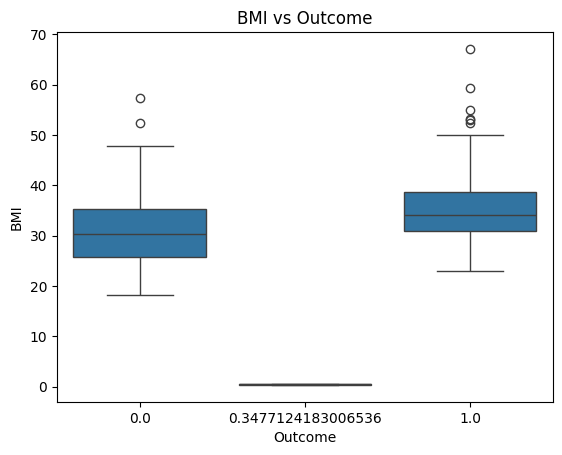

In [12]:
plt.figure()
sns.boxplot(x="Outcome", y="BMI", data=df)
plt.title("BMI vs Outcome")
plt.show()

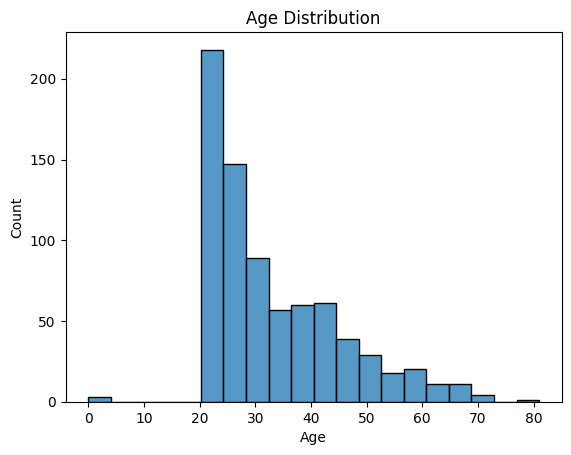

In [13]:
plt.figure()
sns.histplot(df["Age"], bins=20)
plt.title("Age Distribution")
plt.show()

In [14]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"].astype(int)
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [16]:
y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Accuracy: 0.7662337662337663

Confusion Matrix:
 [[83 16]
 [20 35]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.84      0.82        99
           1       0.69      0.64      0.66        55

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.74       154
weighted avg       0.76      0.77      0.76       154



In [17]:
sample = [[2, 120, 70, 20, 85, 30.5, 0.5, 35]]

sample = scaler.transform(sample)
prediction = model.predict(sample)

print("\nPrediction:")
print("Diabetic" if prediction[0] == 1 else "Healthy")


Prediction:
Healthy


c:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


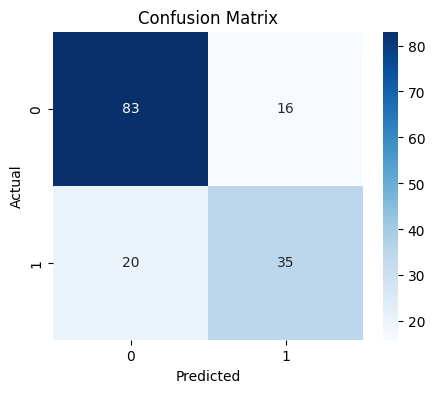

In [18]:
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

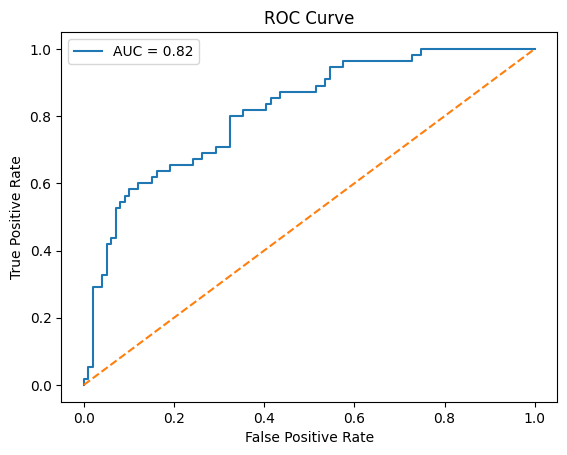

In [19]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("\n=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))


=== Random Forest ===
Accuracy: 0.7337662337662337


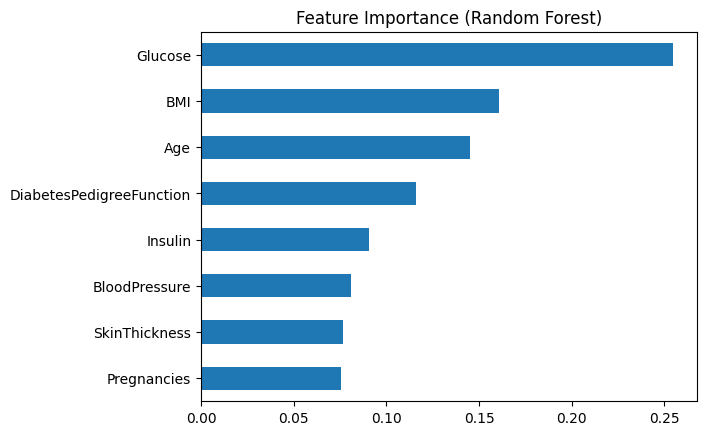

In [21]:
importance = rf_model.feature_importances_
features = df.drop("Outcome", axis=1).columns

feat_imp = pd.Series(importance, index=features)
feat_imp.sort_values().plot(kind='barh')

plt.title("Feature Importance (Random Forest)")
plt.show()


In [22]:
import joblib

joblib.dump(model, "diabetes_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("\nModel and scaler saved!")



Model and scaler saved!


In [23]:
loaded_model = joblib.load("diabetes_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")

new_sample = [[3, 140, 80, 25, 100, 32.0, 0.6, 40]]
new_sample = loaded_scaler.transform(new_sample)

result = loaded_model.predict(new_sample)

print("\nLoaded Model Prediction:")
print("Diabetic" if result[0] == 1 else "Healthy")


Loaded Model Prediction:
Healthy


c:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [24]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X, y, cv=5)

print("\nCross Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())



Cross Validation Scores: [0.75324675 0.74025974 0.79220779 0.79738562 0.77777778]
Mean CV Accuracy: 0.7721755368814192


In [25]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["lbfgs", "liblinear"]
}
grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5)
grid.fit(X_train, y_train)

print("\nBest Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

best_model = grid.best_estimator_



Best Parameters: {'C': 0.1, 'solver': 'lbfgs'}
Best Score: 0.7720245235239238


In [26]:
y_pred_best = best_model.predict(X_test)

print("\n=== Tuned Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))



=== Tuned Logistic Regression ===
Accuracy: 0.7662337662337663
Confusion Matrix:
 [[84 15]
 [21 34]]


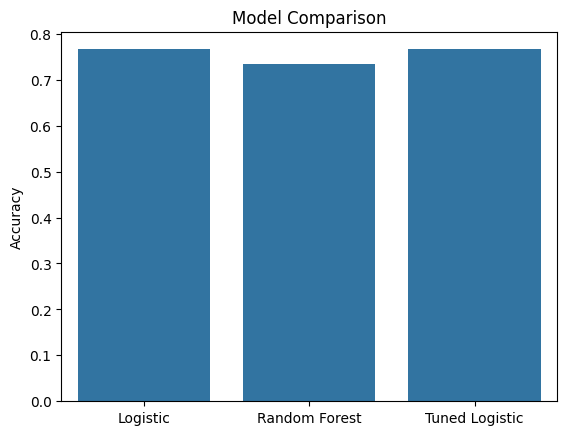

In [27]:
models = ["Logistic", "Random Forest", "Tuned Logistic"]
accuracies = [
    accuracy_score(y_test, y_pred),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_best)
]

plt.figure()
sns.barplot(x=models, y=accuracies)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()